In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [54]:
def f(x):
    return 3*x**2 - 4*x + 5

In [55]:
f(3.0)

20.0

In [56]:
xs = np.arange(-5, 5, 0.25)

In [57]:
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [58]:
ys = f(xs)

In [59]:
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

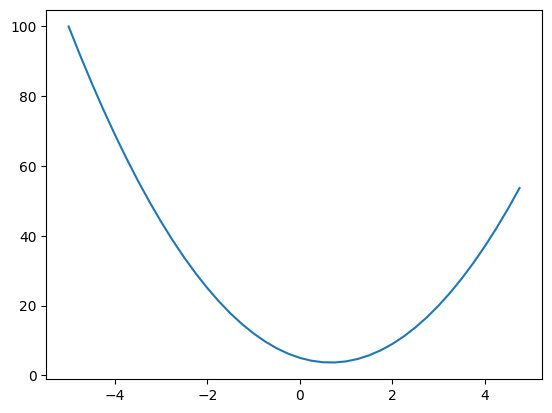

In [60]:
plt.plot(xs, ys)

In [61]:
h = 0.0001
x = 2/3
(f(x+h) - f(x))/h

0.0002999999981767587

In [62]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [63]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
# a += h
# b += h
c += h
d2 = a*b + c

slope = (d2-d1)/h

{"d1": d1, "d2": d2, "slope": slope}

{'d1': 4.0, 'd2': 4.0001, 'slope': 0.9999999999976694}

In [64]:
class Value:

    def __init__(self, data, _parents=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_parents)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            # derivative of tan is 1 - tan^2
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(self):
            if self not in visited:
                visited.add(self)
                for c in self._prev:
                    build_topo(c)
                topo.append(self)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


In [65]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [66]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    # https://graphviz.org/docs/attrs/rankdir/
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # https://graphviz.org/doc/info/shapes.html#html
        dot.node(
            name=uid,
            label=f'''<<TABLE BORDER="0" CELLBORDER="1" CELLSPACING="0">
              <TR>
                <TD CELLPADDING="6">{n.label}</TD>
                <TD CELLPADDING="6">data {n.data:.4f}</TD>
                <TD CELLPADDING="6">grad {n.grad:.4f}</TD>
              </TR>
            </TABLE>>''',
            shape='plain'
        )
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid+n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid+n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

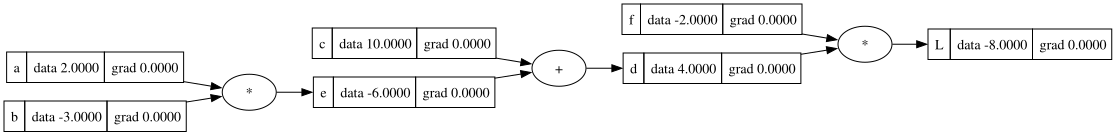

In [67]:
draw_dot(L)

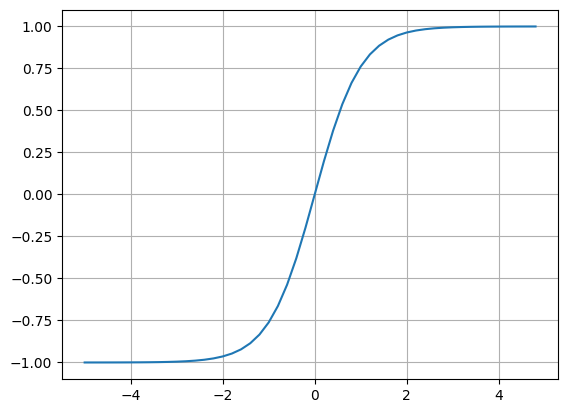

In [68]:
plt.plot(
    np.arange(-5, 5, 0.2),
    np.tanh(np.arange(-5, 5, 0.2))
)
plt.grid()

In [69]:
# input
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.88137, label='b')

x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1 + x2w2'

n = x1w1x2w2 + b; n.label='n'

o = n.tanh(); o.label='o'

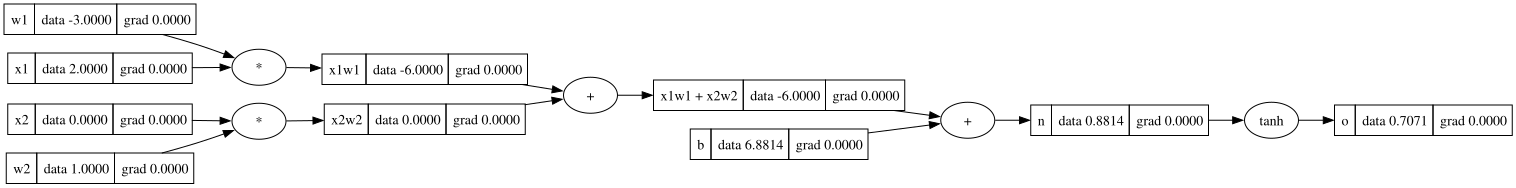

In [70]:
draw_dot(o)

In [71]:
o.backward()

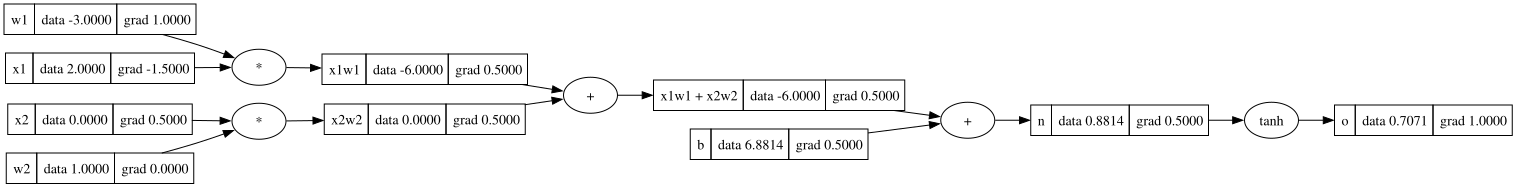

In [72]:
draw_dot(o)

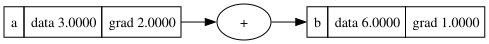

In [73]:
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

In [74]:
class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs

class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

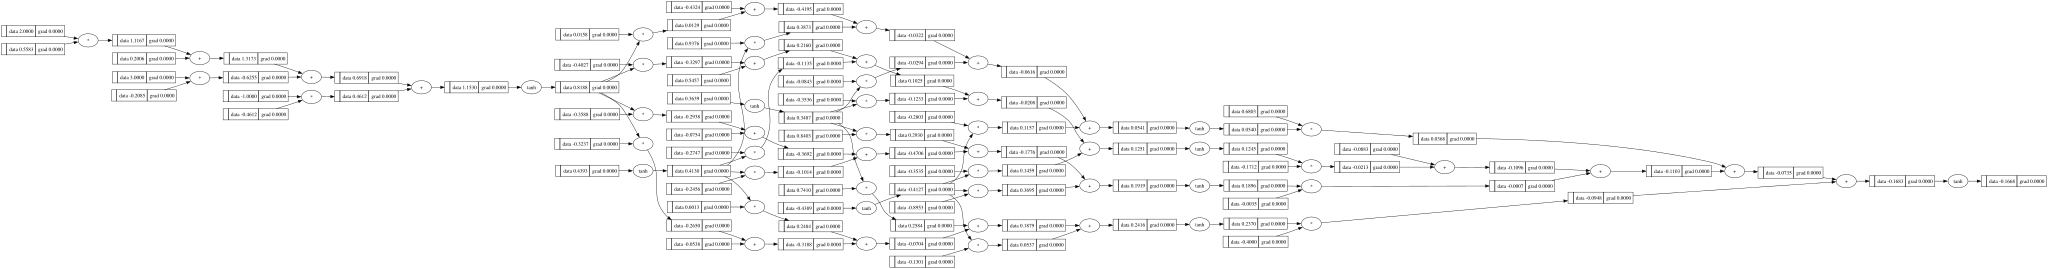

In [79]:
n = MLP(3, [4, 4, 1])
x = map(Value, [2.0, 3.0, -1.0])
[o] = n(x)
draw_dot(o)

In [4]:
def f(a, b, c):
  return -a**3 + math.sin(3*b) - 1.0/c + b**2.5 - a**0.5

f(2, 3, 4)

6.336362190988558

In [6]:
# analytical gradient of f
# https://www.wolframalpha.com/input?i=d%2Fda%28sin%283*a%29%29%29

def gradf(a, b, c):
   # return [df/da, df/db, df/dc]
  return [
      -(3*(a**2.5 + 1/6))/(a**0.5),
      (2.5)*(b**1.5) + 3*math.cos(3*b),
      1/(c**2)
  ]

# expected answer is the list of
ans = [-12.353553390593273, 10.25699027111255, 0.0625]
yours = gradf(2, 3, 4)
for dim in range(3):
  ok = 'OK' if abs(yours[dim] - ans[dim]) < 1e-5 else 'WRONG!'
  print(f"{ok} for dim {dim}: expected {ans[dim]}, yours returns {yours[dim]}")


OK for dim 0: expected -12.353553390593273, yours returns -12.353553390593275
OK for dim 1: expected 10.25699027111255, yours returns 10.25699027111255
OK for dim 2: expected 0.0625, yours returns 0.0625
